<a href="https://colab.research.google.com/github/psvprasad2003/SAMPLE_ML_MODELS/blob/main/AE_RANDOM%20FOREST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive Maintenance for Airplane Engines
We will use a Random Forest Classifier to predict maintenance needs based on the provided engine record data.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# Inspect sheet names to find the correct data table
file_path = '/content/136552_136553_A_B_RECORDS_AI_ML_AUGMENTED.xlsx'
xl = pd.ExcelFile(file_path)
print(f'Available sheets: {xl.sheet_names}')

# Load the sheet that likely contains the maintenance records
# We'll try to load the second sheet if available, otherwise stay with the first
sheet_to_load = xl.sheet_names[1] if len(xl.sheet_names) > 1 else xl.sheet_names[0]
df = pd.read_excel(file_path, sheet_name=sheet_to_load)

# Display basic information
print(f'Loaded sheet: {sheet_to_load}')
print(df.info())
display(df.head())

Available sheets: ['AI_ML_SUMMARY', '136552_INCIDENT_RECORD_A', '136552_INCIDENT_RECORD_B', '136553_INCIDENT_RECORD_A', '136553_INCIDENT_RECORD_B']
Loaded sheet: 136552_INCIDENT_RECORD_A
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1861 entries, 0 to 1860
Data columns (total 54 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   SOURCE                         1861 non-null   object        
 1   ECU Operating Time             1861 non-null   float64       
 2   Leg Number                     1861 non-null   int64         
 3   N1                             1861 non-null   float64       
 4   N2                             1861 non-null   float64       
 5   EGT                            1861 non-null   float64       
 6   ITT Display                    1861 non-null   float64       
 7   ECU TT2                        1861 non-null   float64       
 8   ECU PS                         

,SOURCE,ECU Operating Time,Leg Number,N1,N2,EGT,ITT Display,ECU TT2,ECU PS,CGV position,...,Incident Type,Engine Serial,Record Origin,Synthetic Fault Category,Fault Record Description,Fault Severity,Target Spare Part,Suggested Maintenance Action,ML Fault Label,Synthetic Record ID
0,SOURCE_1,21997812.9,2740,52.25,79.31,386.75,484.38,14.19,13.79,42.11,...,INCIDENT_RECORD_A | Event Trigger 0,136552,ORIGINAL,Observed incident record,Original source record retained without altera...,Observed,To be determined from maintenance records,Use approved maintenance documentation and eng...,OBSERVED_INCIDENT,NaN
1,SOURCE_1,21997814.9,2740,50.77,79.36,394.19,484.38,14.16,13.80,41.72,...,INCIDENT_RECORD_A | Event Trigger 0,136552,ORIGINAL,Observed incident record,Original source record retained without altera...,Observed,To be determined from maintenance records,Use approved maintenance documentation and eng...,OBSERVED_INCIDENT,NaN
2,SOURCE_1,21997816.9,2740,50.61,79.30,395.94,486.38,14.09,13.81,41.81,...,INCIDENT_RECORD_A | Event Trigger 0,136552,ORIGINAL,Observed incident record,Original source record retained without altera...,Observed,To be determined from maintenance records,Use approved maintenance documentation and eng...,OBSERVED_INCIDENT,NaN
3,SOURCE_1,21997818.9,2740,50.56,79.28,396.00,486.25,14.03,13.82,41.81,...,INCIDENT_RECORD_A | Event Trigger 0,136552,ORIGINAL,Observed incident record,Original source record retained without altera...,Observed,To be determined from maintenance records,Use approved maintenance documentation and eng...,OBSERVED_INCIDENT,NaN
4,SOURCE_1,21997820.9,2740,49.94,78.61,394.56,485.00,14.02,13.83,42.79,...,INCIDENT_RECORD_A | Event Trigger 0,136552,ORIGINAL,Observed incident record,Original source record retained without altera...,Observed,To be determined from maintenance records,Use approved maintenance documentation and eng...,OBSERVED_INCIDENT,NaN


In [ ]:
# Data Preprocessing for the full dataset
# We'll use 'ML Fault Label' as the target for classification
target_col = 'ML Fault Label'

# Selecting numeric features for the model and the target
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
# Dropping columns that are likely identifiers or constants
features_to_drop = ['Engine Serial', 'Incident Year', 'GMT Date', 'GMT Time', 'Unnamed: 39']
X = df[[col for col in numeric_features if col not in features_to_drop]]
y = df[target_col]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Features used: {list(X.columns)}")
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Features used: ['ECU Operating Time', 'Leg Number', 'N1', 'N2', 'EGT', 'ITT Display', 'ECU TT2', 'ECU PS', 'CGV position', 'Power Lever Angle', 'Vibration Average', 'Oil Temperature', 'Oil Pressure', 'Fuel Temperature', 'Main Metering Valve', 'Fuel Usage', 'P3', 'Mach', 'Altitude', 'Overspeed Status Word 2', 'Overspeed Status Word 3', 'ITT TRIM', 'Right TR Stow Switch Position', 'Left TR Stow Switch Position', 'TR Deploy Switch Position', 'Engine Status Word 1', 'Engine Status Word 2', 'Engine Status Word 3', 'Engine Status Word 4', 'Latitude', 'Longitude', 'Event Trigger', 'event_status_word1', 'EQA/N1 Compensation Value', 'MMV Torque Motor Current', 'CGV Torque Motor Current']
Training set size: (1488, 36)
Testing set size: (373, 36)


Accuracy Score: 1.0

Classification Report:
                          precision    recall  f1-score   support

FAULT_BEARING_VIBRATION       1.00      1.00      1.00        19
       FAULT_COMPRESSOR       1.00      1.00      1.00        13
    FAULT_FUEL_METERING       1.00      1.00      1.00        15
      FAULT_HOT_SECTION       1.00      1.00      1.00        17
      FAULT_LUBRICATION       1.00      1.00      1.00        17
FAULT_OVERSPEED_CONTROL       1.00      1.00      1.00        10
  FAULT_SENSOR_ACTUATOR       1.00      1.00      1.00         9
      OBSERVED_INCIDENT       1.00      1.00      1.00       273

               accuracy                           1.00       373
              macro avg       1.00      1.00      1.00       373
           weighted avg       1.00      1.00      1.00       373



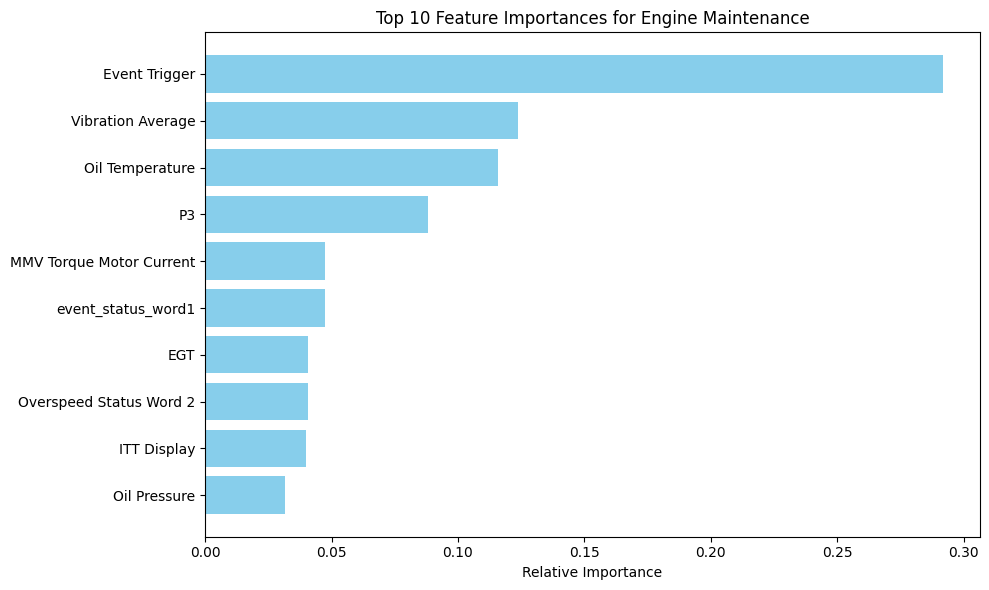

In [ ]:
# Initialize and train the Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:] # Top 10 features

plt.figure(figsize=(10, 6))
plt.title('Top 10 Feature Importances for Engine Maintenance')
plt.barh(range(len(indices)), importances[indices], align='center', color='skyblue')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

### Confusion Matrix Visualization
We will visualize the confusion matrix to see how the model performs for each specific fault class.

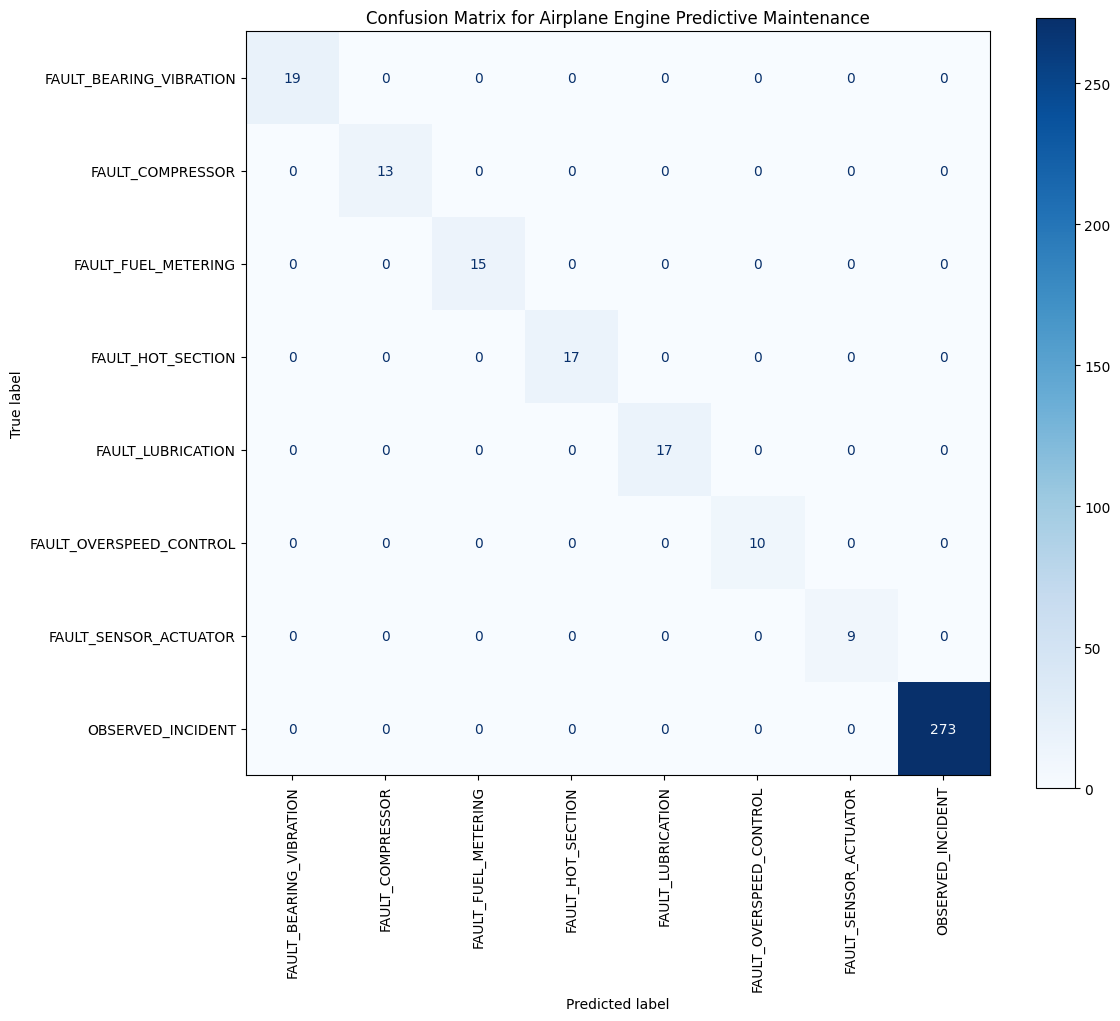

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)

# Display the confusion matrix
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(ax=ax, cmap='Blues', xticks_rotation='vertical')
plt.title('Confusion Matrix for Airplane Engine Predictive Maintenance')
plt.show()